In [3]:

from utils.ROI import roi


In [4]:
def detect_wand(wand_mask):
    """
    detect the wand based on a given mask 
    return True wand detected False otherwise 
    
    """
    threshold = 50 # pixel 
    status = False 
    # now we count how much white pixel we have on the new mask 
    n_pixel = np.shape(np.where(wand_mask == 1))[1]  # mask should be binary 0/1
    print("detect pixel = " , n_pixel)
    print("threshold" , threshold)
    if n_pixel <= threshold  :
        print("there is NOT enough pixel to consider  the wand as detected so we do not change the color")
    else :
    # if we are here it means that we detected the wand 
        print("there is  enough pixel to consider the wand  as detected to apply the trick 2")
        status = True 
    return status 

In [ ]:
def do_trick2_1obj(img, obj_mask, wand_mask):

    out = roi(obj_mask , s_erod=10 , s_dil=200)
    new_image, roi_mask  = out[0] , out[1]
    # here since new image is only restricted to the object ROI
    # we want to detect the wand  
    status =  detect_wand(wand_mask)
    
    if status == False :
        return img # we finish here no change to do git
    
    # now we start the changing color process 
    orig_rgb   = RGB
    target_rgb = [200,5,6] # to be changed !!!!!!
    img_test = change_color_mask(new_image,orig_rgb, target_rgb , obj_mask)
    print("img_test have a shape of ",np.shape(img_test))
    
    mask_inv = cv.bitwise_not(roi_mask)
    img_not_processed = cv.bitwise_and(img,img, mask=mask_inv)
    if not np.shape(img_not_processed)== np.shape(img_test):
        print("There is something wrong with the shape of img_not_processed and img_test")
        return result , False 
    combined = cv2.add(img_test, img_not_processed)
    print(" the combination of the processed and unprocessed part work successfully")
    return combined  , True 

In [42]:
def plot_contours(img , s= 5):
    #img = cv.medianBlur(img,19)
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
	
    # Otsu's thresholding after Gaussian filtering
    blur = cv.GaussianBlur(img_gray,(5,5),0)
    ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
    
    # apply binary thresholding
    th4 = cv.adaptiveThreshold(img_gray,255,
                               cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
                               cv.THRESH_BINARY_INV,
                               5,
                               2)  
    # visualize the binary image
    plt.imshow(cv.cvtColor(th3,cv.COLOR_BGR2RGB))
    plt.axis("off")
    return 0

0

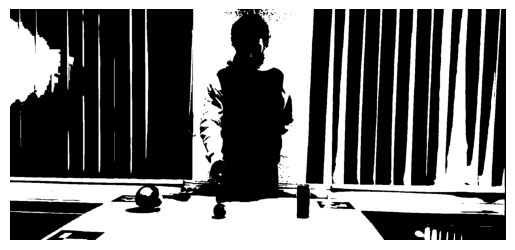

In [43]:
import cv2  as cv
import matplotlib.pyplot as plt  
import numpy as np
img = cv.imread("data/oneFramewithWand.png")
plot_contours(img)


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [29]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

def detect_objects(image_path):
    """
    Detect objects in an image using YOLOv8.
    
    Args:
        image_path: Path to the input image
    
    Returns:
        Detected objects and class labels.
    """
    # Load YOLO model
    model = YOLO('yolov9m.pt')  # Load the model
    
    # Read image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Perform detection
    results = model(image_rgb)[0]
    
    # Create a copy of the image for drawing
    annotated_image = image_rgb.copy()
    
    # Generate random colors for classes
    np.random.seed(42)  # For consistent colors
    colors = np.random.randint(0, 255, size=(100, 3), dtype=np.uint8)
    
    # To hold class names and their corresponding colors
    class_labels = {}
    
    # Process detections
    boxes = results.boxes

    return boxes, results.names, annotated_image, colors

def show_results(image_path, confidence_threshold):
    """
    Show original image and detection results side by side.

    Args:
        image_path: Path to the input image
        confidence_threshold: Minimum confidence score for detections
    """
    # Read original image
    original_image = cv2.imread(image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    
    # Get detection results
    boxes, class_names, annotated_image, colors = detect_objects(image_path)
    
    # Process each detected object and apply confidence threshold filtering
    class_labels = {}
    for box in boxes:
        # Get box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        # Get confidence score
        confidence = float(box.conf[0])
        
        # Only show detections above confidence threshold
        if confidence > confidence_threshold:
            # Get class id and name
            class_id = int(box.cls[0])
            class_name = class_names[class_id]
            
            # Get color for this class
            color = colors[class_id % len(colors)].tolist()
            
            # Draw bounding box
            cv2.rectangle(annotated_image, (x1, y1), (x2, y2), color, 2)
            
            # Store class name and color for legend
            class_labels[class_name] = color

    # Create figure
    plt.figure(figsize=(15, 7))
    
    # Show original image
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(original_image)
    plt.axis('off')
    
    # Show detection results
    plt.subplot(1, 2, 2)
    plt.title('Detected Objects')
    plt.imshow(annotated_image)
    plt.axis('off')

    # Create legend
    legend_handles = []
    for class_name, color in class_labels.items():
        normalized_color = np.array(color) / 255.0  # Normalize the color
        legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=class_name,
                                           markerfacecolor=normalized_color, markersize=10))

    plt.legend(handles=legend_handles, loc='upper right', title='Classes')

    plt.tight_layout()
    plt.show()



0: 320x640 1 person, 1 sports ball, 1 orange, 310.1ms
Speed: 16.6ms preprocess, 310.1ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 640)


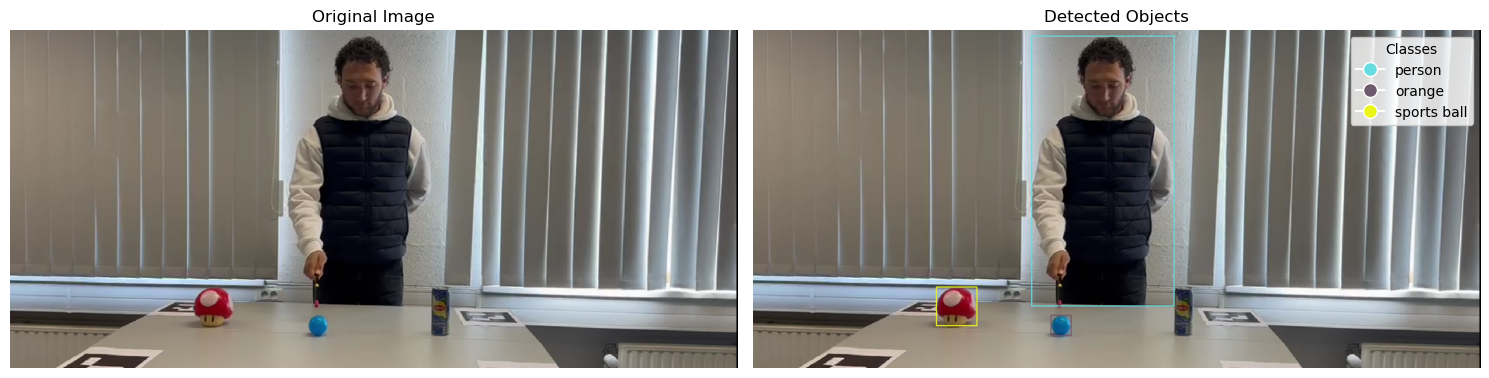

In [30]:
# Example usage:
show_results('data/oneFramewithWand.png', confidence_threshold=0.0)

In [34]:
# Load YOLO model once (do this outside the function)
model = YOLO('yolov9m.pt')

# Generate consistent colors for classes
np.random.seed(42)
colors = np.random.randint(0, 255, size=(100, 3), dtype=np.uint8)

def annotate_frame(frame):
    """
    Detect objects on a single frame and draw bounding boxes.

    Args:
        frame (np.ndarray): Input image/frame in BGR format
        confidence_threshold (float): Minimum confidence to draw box

    Returns:
        np.ndarray: Annotated frame with bounding boxes
    """
    confidence_threshold=0.3
    # YOLO expects RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Perform detection
    results = model(rgb_frame)[0]
    boxes = results.boxes
    class_names = results.names

    # Make a copy to draw on
    annotated_frame = frame.copy()

    # Draw boxes
    for box in boxes:
        conf = float(box.conf[0])
        if conf < confidence_threshold:
            continue
        class_id = int(box.cls[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = colors[class_id % len(colors)].tolist()
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated_frame, f"{class_names[class_id]} {conf:.2f}", 
                    (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return annotated_frame

# Now Test with YOLO

In [35]:
import cv2 as cv 
import matplotlib.pyplot as plt 
import numpy as np 
from ultralytics import YOLO
from utils.video import *

#detect object That is good (relatively)
in_path  = "data/group_11_fixed.mp4"       
out_path = "output/fixed_test.mp4"
apply_function_to_video(in_path, out_path, annotate_frame)



0: 384x640 (no detections), 324.6ms
Speed: 17.2ms preprocess, 324.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 287.4ms
Speed: 3.1ms preprocess, 287.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 537.9ms
Speed: 1.6ms preprocess, 537.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 293.0ms
Speed: 1.5ms preprocess, 293.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 268.8ms
Speed: 1.7ms preprocess, 268.8ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 265.1ms
Speed: 1.6ms preprocess, 265.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 283.4ms
Speed: 1.3ms preprocess, 283.4ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 281.6ms
Speed: 1.3ms prep

KeyboardInterrupt: 